# Walk Forward Cross-Validation

Standard cross-validation techniques do not account for time dependency and thus cannot be used in time-series regressions. Walk forward cross-validation allow to dompute test MSE while accounting for time dependency. In particular, it takes two forms:

- Expanding window: the training sample size increases over time
- Rolling window: fixed training sample size

Consider the following example. We are interested in predicting future returns on the S\&P500 using contemporaneous returns

$$
r_{t} = \alpha + \sum_{h=1}^5\beta_h r_{t-h} + \epsilon_t
$$

We apply both expanding and rolling window walk forward cross-validation.

## 0. Required packages

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

## 1. Retrieve and prepare data

We retrieve S&P500 returns using `yfinance` and construct lagged returns $r_{t-h}$, with $h={1, 2, 3, 4, 5}$.

In [2]:
# ----------------------------
# 1) Download S&P 500 monthly returns
# ----------------------------
ticker = "^GSPC"
start, end = "2000-01-01", "2025-12-31"

raw = yf.download(ticker, start=start, end=end, interval="1mo", progress=False, auto_adjust=True)
px = raw["Adj Close"] if "Adj Close" in raw.columns else raw["Close"]
ret = px.pct_change().dropna()
ret.columns = ["y"]

# ----------------------------
# 2) Create lagged features: r_{t-1} ... r_{t-5}
# ----------------------------
lags = [1, 2, 3, 4, 5]
for h in lags:
    ret[f"x_lag{h}"] = ret["y"].shift(h)
ret = ret.dropna()

dates = ret.index
feature_cols = [f"x_lag{h}" for h in lags]
X = ret[feature_cols].values
y = ret["y"].values
n = len(ret)

## 2. Expanding window

We set the minimum size for training the model equal to 100 observations. The test sample size is equal to one. 

In [3]:
# ----------------------------
# 3) Walk-forward parameters
# ----------------------------
min_train = 100
test_size = 1
rolling_window = 150

# ----------------------------
# 4) Expanding Window
# ----------------------------
expanding_mse = []
expanding_dates = []

for i in range(min_train, n - test_size + 1):
    X_tr, y_tr = X[:i], y[:i]
    X_te, y_te = X[i:i + test_size], y[i:i + test_size]

    model = LinearRegression().fit(X_tr, y_tr)
    pred = model.predict(X_te)
    expanding_mse.append(mean_squared_error(y_te, pred))
    expanding_dates.append(dates[i])

## 3. Rolling window

The size of the rolling window is set to 150 observations

In [4]:
# ----------------------------
# 5) Rolling Window
# ----------------------------
rolling_mse = []
rolling_dates = []

for i in range(rolling_window, n - test_size + 1):
    tr_start = i - rolling_window
    X_tr, y_tr = X[tr_start:i], y[tr_start:i]
    X_te, y_te = X[i:i + test_size], y[i:i + test_size]

    model = LinearRegression().fit(X_tr, y_tr)
    pred = model.predict(X_te)
    rolling_mse.append(mean_squared_error(y_te, pred))
    rolling_dates.append(dates[i])

## 4. Summary statistics and plot

Features: ['x_lag1', 'x_lag2', 'x_lag3', 'x_lag4', 'x_lag5']
Expanding window — avg MSE: 0.002014  (over 206 folds)
Rolling   window — avg MSE: 0.001833  (over 156 folds)


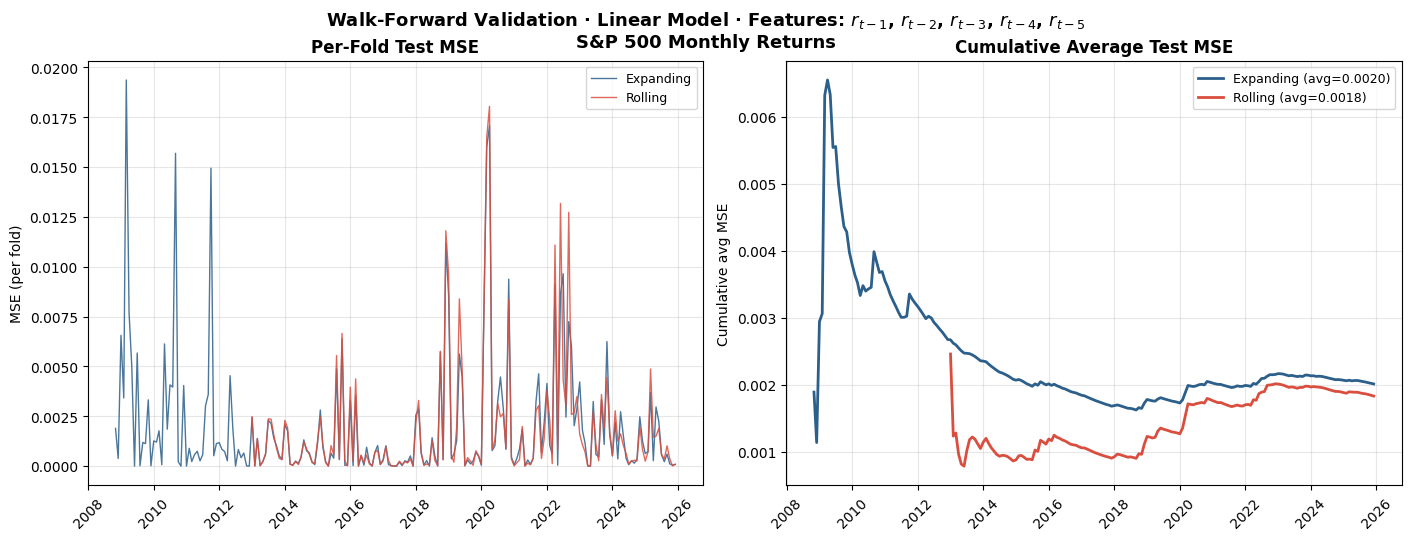

In [6]:
#### ----------------------------
# 6) Summary statistics
# ----------------------------
exp_avg = np.mean(expanding_mse)
rol_avg = np.mean(rolling_mse)
print(f"Features: {feature_cols}")
print(f"Expanding window — avg MSE: {exp_avg:.6f}  (over {len(expanding_mse)} folds)")
print(f"Rolling   window — avg MSE: {rol_avg:.6f}  (over {len(rolling_mse)} folds)")

# ----------------------------
# 7) Two-panel figure with dates on x-axis
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

c_exp = "#2C5F8A"
c_rol = "#D94E3F"

# ── Left: Per-fold MSE ──
ax = axes[0]
ax.plot(expanding_dates, expanding_mse, color=c_exp, linewidth=1.0, alpha=0.85, label="Expanding")
ax.plot(rolling_dates, rolling_mse, color=c_rol, linewidth=1.0, alpha=0.85, label="Rolling")
ax.set_ylabel("MSE (per fold)")
ax.set_title("Per-Fold Test MSE", fontweight="bold", fontsize=12)
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)

# ── Right: Cumulative average MSE ──
ax = axes[1]
cum_exp = np.cumsum(expanding_mse) / np.arange(1, len(expanding_mse) + 1)
cum_rol = np.cumsum(rolling_mse) / np.arange(1, len(rolling_mse) + 1)
ax.plot(expanding_dates, cum_exp, color=c_exp, linewidth=2, label=f"Expanding (avg={exp_avg:.4f})")
ax.plot(rolling_dates, cum_rol, color=c_rol, linewidth=2, label=f"Rolling (avg={rol_avg:.4f})")
ax.set_ylabel("Cumulative avg MSE")
ax.set_title("Cumulative Average Test MSE", fontweight="bold", fontsize=12)
ax.legend(frameon=True, fontsize=9)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.tick_params(axis="x", rotation=45)

lag_str = ", ".join([f"$r_{{t-{h}}}$" for h in lags])
fig.suptitle(f"Walk-Forward Validation · Linear Model · Features: {lag_str}\nS&P 500 Monthly Returns",
             fontsize=13, fontweight="bold", y=1.05)

plt.savefig("Ch4_WalkForward.png", dpi=300, bbox_inches="tight")